# 📊 RAG Evaluation & Visualization

Evaluates RAG retrieval performance from **pre-computed** results (saved by `rag_retrieval.ipynb`).

## Prerequisites
Run `rag_retrieval.ipynb` first to generate `results_{strategy}.parquet` files.

## Structure
1. **Setup** — Config, load results, compute metrics & derived columns
2. **Distribution** — Question & corpus popularity distributions (understand the data)
3. **Performance** — Recall@K, MRR, and per-decile performance (how well does retrieval work?)
4. **Fairness Analysis** — Popularity bias heatmaps, preference curves, wrong retrieval origins (is it unfair?)
5. **Export** — Save results & inspect samples

## 1. Configuration

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv

from config import DATA_DIR


load_dotenv()

# ============================================================================
# Evaluation Configuration
# ============================================================================

OUTPUT_NAME = "nq_500"  

# Collection & Index
COLLECTION_NAME = "wiki_full"
COLLECTION_ROOT = Path(DATA_DIR) / COLLECTION_NAME
QUESTIONS_PATH = COLLECTION_ROOT / f"{OUTPUT_NAME}.parquet"
CORPUS_PATH = COLLECTION_ROOT / "wiki_corpus.parquet"

# Retrieval Configuration
STRATEGIES = ["approximation", "bm25"]  # Must match what was used in rag_retrieval.ipynb
TOP_K = 10  # Primary metric for reporting
K_VALUES_DETAILED = [1,3,5,10]  # K values for investigation/curves

# Decile Configuration
USE_WEIGHTED_DECILES = True  # True: use chunk-weighted boundaries (reflects index distribution)
                             # False: use unweighted boundaries (1 doc = 1 count)

# Output Configuration
OUTPUT_FOLDER = OUTPUT_NAME
RESULTS_DIR = COLLECTION_ROOT / OUTPUT_FOLDER
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Config loaded")
print(f"  Collection: {COLLECTION_NAME}")
print(f"  Results dir: {RESULTS_DIR}")
print(f"  Strategies: {STRATEGIES}")
print(f"  Top-K (Primary): {TOP_K}")
print(f"  K-Values (Detailed): {K_VALUES_DETAILED}")
print(f"  Decile Weighting: {'Weighted (chunk-based)' if USE_WEIGHTED_DECILES else 'Unweighted (doc-based)'}")

✓ Config loaded
  Collection: wiki_full
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/nq_500
  Strategies: ['approximation', 'bm25']
  Top-K (Primary): 10
  K-Values (Detailed): [1, 3, 5, 10]
  Decile Weighting: Weighted (chunk-based)


## 2. Load Pre-Computed Retrieval Results

Load the `results_{strategy}.parquet` files generated by `rag_retrieval.ipynb`.  
No Elasticsearch connection is needed — all retrieval data is already on disk.

In [2]:
print("Loading pre-computed retrieval results...\n")

results_by_strategy = {}

for strategy in STRATEGIES:
    results_path = RESULTS_DIR / f"results_{strategy}.parquet"
    if not results_path.exists():
        print(f"  ⚠ Missing: {results_path} — run rag_retrieval.ipynb first!")
        continue
    
    df = pd.read_parquet(results_path)
    results_by_strategy[strategy] = df
    print(f"  ✓ {strategy}: {len(df):,} rows loaded from {results_path.name}")

ALL_STRATEGIES = list(results_by_strategy.keys())

if not ALL_STRATEGIES:
    raise FileNotFoundError("No retrieval results found! Run rag_retrieval.ipynb first.")

print(f"\n✓ Loaded {len(ALL_STRATEGIES)} strategies: {', '.join(ALL_STRATEGIES)}")
print(f"\nSample data:")
display(results_by_strategy[ALL_STRATEGIES[0]].head(3))

Loading pre-computed retrieval results...

  ✓ approximation: 2,227 rows loaded from results_approximation.parquet
  ✓ bm25: 2,227 rows loaded from results_bm25.parquet

✓ Loaded 2 strategies: approximation, bm25

Sample data:


,question,wikipedia_id,wikipedia_title,decile,popularity_avg,dataset,topk_ids,topk_scores,topk_popularities,pop_decile
0,who is the current leader of the official oppo...,711418,List of Leaders of the Official Opposition (Ca...,0,1.866667,natural_questions,"[382895, 711418, 48456232, 48459189]","[0.95519114, 0.9458517, 0.9440953, 0.9433629]","[6187.604166666667, 1.8666666666666665, 73632....",0
1,who played corde in attack of the clones,7232669,Verónica Segura,0,7.287037,natural_questions,"[3448168, 55447, 4228260, 811060]","[0.92034066, 0.9179969, 0.91650736, 0.9152733]","[11463.479166666666, 77835.6875, 4192.375, 701...",0
2,who is the education minister of pakistan 2018,17201259,Minister for Education (Pakistan),0,2.428571,natural_questions,"[17201259, 59077089, 53475738, 56313882]","[0.9505099, 0.93422806, 0.93324053, 0.93188703]","[2.428571428571429, 195.5625, 3302.77083333333...",0


## 3. Compute Metrics & Prepare Data

Calculate **Recall@K**, **MRR**, rank statistics, and derived columns for all strategies.  
This single cell prepares everything needed for all subsequent visualizations.

In [3]:
# ============================================================================
# Metric Functions
# ============================================================================

def compute_metrics(results_df, k_values=K_VALUES_DETAILED):
    """Compute retrieval metrics."""
    metrics = {}

    for k in k_values:
        def recall_at_k(row, _k=k):
            topk = row["topk_ids"][:_k] if len(row["topk_ids"]) >= _k else row["topk_ids"]
            return 1.0 if row["wikipedia_id"] in topk else 0.0
        results_df[f"recall@{k}"] = results_df.apply(recall_at_k, axis=1)
        metrics[f"recall@{k}"] = results_df[f"recall@{k}"].mean()

    def get_reciprocal_rank(row):
        try:
            topk = list(row["topk_ids"]) if hasattr(row["topk_ids"], "__iter__") else []
            rank = topk.index(row["wikipedia_id"]) + 1
            return 1.0 / rank
        except (ValueError, AttributeError, TypeError):
            return 0.0

    results_df["reciprocal_rank"] = results_df.apply(get_reciprocal_rank, axis=1)
    metrics["mrr"] = results_df["reciprocal_rank"].mean()

    def get_rank(row):
        try:
            topk = list(row["topk_ids"]) if hasattr(row["topk_ids"], "__iter__") else []
            return topk.index(row["wikipedia_id"]) + 1
        except (ValueError, AttributeError, TypeError):
            return None

    results_df["rank"] = results_df.apply(get_rank, axis=1)
    found_ranks = results_df["rank"].dropna()
    metrics["median_rank"] = found_ranks.median() if len(found_ranks) > 0 else None
    metrics["mean_rank"] = found_ranks.mean() if len(found_ranks) > 0 else None

    return metrics, results_df


def get_found_rank(row):
    try:
        topk = list(row["topk_ids"]) if hasattr(row["topk_ids"], "__iter__") else []
        return topk.index(row["wikipedia_id"]) + 1
    except (ValueError, AttributeError, TypeError):
        return None


def get_wrong_pops(row):
    wrong_pops = []
    topk_ids = list(row["topk_ids"]) if hasattr(row["topk_ids"], "__iter__") else []
    topk_pops = list(row["topk_popularities"]) if hasattr(row["topk_popularities"], "__iter__") else []

    for i, doc_id in enumerate(topk_ids):
        if doc_id != row["wikipedia_id"] and i < len(topk_pops):
            if topk_pops[i] is not None:
                wrong_pops.append(topk_pops[i])
    return wrong_pops if wrong_pops else None


# ============================================================================
# Compute Metrics
# ============================================================================

print("Computing metrics for all strategies...\n")

k_values_full = list(range(1, max(TOP_K, max(K_VALUES_DETAILED)) + 1))

metrics_by_strategy = {}
for strategy, results_df in results_by_strategy.items():
    metrics, results_df = compute_metrics(results_df, k_values_full)
    metrics_by_strategy[strategy] = metrics
    results_by_strategy[strategy] = results_df

    print(f"{'='*60}")
    print(f"{strategy.upper()} METRICS")
    print(f"{'='*60}")
    for k in K_VALUES_DETAILED:
        print(f"  recall@{k}: {metrics[f'recall@{k}']:.4f}")
    if TOP_K not in K_VALUES_DETAILED:
        print(f"  recall@{TOP_K} (PRIMARY): {metrics[f'recall@{TOP_K}']:.4f}")
    print(f"  mrr: {metrics['mrr']:.4f}")
    if metrics["median_rank"] is not None:
        print(f"  median_rank: {metrics['median_rank']:.1f}")
    if metrics["mean_rank"] is not None:
        print(f"  mean_rank: {metrics['mean_rank']:.1f}")
    print()

metrics_df = pd.DataFrame(metrics_by_strategy).T
metrics_df.to_csv(RESULTS_DIR / "metrics_comparison.csv")


# ============================================================================
# Corpus Decile Boundaries (loaded from metadata.json)
# — MUST come before pop_decile assignment so questions are binned correctly
# ============================================================================

import json

metadata_path = RESULTS_DIR / "metadata.json"
if metadata_path.exists():
    with open(metadata_path) as f:
        metadata = json.load(f)

    if USE_WEIGHTED_DECILES:
        if "decile_boundaries_chunk_weighted" in metadata:
            corpus_bin_edges = np.array(metadata["decile_boundaries_chunk_weighted"])
            print("✓ Loaded chunk-weighted decile boundaries from metadata.json")
        else:
            raise ValueError("USE_WEIGHTED_DECILES is True but 'decile_boundaries_chunk_weighted' not found in metadata.json")
    else:
        if "decile_boundaries_unweighted" in metadata:
            corpus_bin_edges = np.array(metadata["decile_boundaries_unweighted"])
            print("✓ Loaded unweighted decile boundaries from metadata.json")
        else:
            raise ValueError("USE_WEIGHTED_DECILES is False but 'decile_boundaries_unweighted' not found in metadata.json")

    print(f"  Boundaries: {[f'{b:.4f}' for b in corpus_bin_edges]}")
    if "corpus_stats" in metadata:
        stats = metadata["corpus_stats"]
        print(f"  Corpus: {stats.get('total_documents', '?'):,} docs → {stats.get('total_chunks_after_splitting', '?'):,} chunks")
else:
    raise FileNotFoundError(f"metadata.json not found in {RESULTS_DIR}. Run rag_retrieval.ipynb first to generate it with decile boundaries.")


print("Computing derived columns...")

for strategy_name in ALL_STRATEGIES:
    df = results_by_strategy[strategy_name]

        # Weighted mode (or forced recompute): derive deciles from boundaries
    df["pop_decile"] = pd.cut(
        df["popularity_avg"],
        bins=corpus_bin_edges,
        labels=False,
        include_lowest=True,
    ).astype("Int64")

    # Normalize dtype and drop rows with missing decile
    df = df[df["pop_decile"].notna()].copy()
    df["pop_decile"] = df["pop_decile"].astype(int)

    df["found_at_rank"] = df.apply(get_found_rank, axis=1)
    df["wrong_docs_popularities"] = df.apply(get_wrong_pops, axis=1)
    results_by_strategy[strategy_name] = df

    print(f"  Recomputed pop_decile using {'chunk-weighted' if USE_WEIGHTED_DECILES else 'unweighted'} boundaries")
else:
    print("  Kept existing pop_decile labels for unweighted mode (with parity diagnostics)")


# ============================================================================
# Per-Decile Metrics  (uses finalized pop_decile)
# ============================================================================

print("Computing per-decile metrics...")

decile_metrics_by_strategy = {}
k_range_full = list(range(1, max(TOP_K, max(K_VALUES_DETAILED)) + 1))

for strategy in ALL_STRATEGIES:
    rdf = results_by_strategy[strategy]
    valid_results = rdf[rdf["pop_decile"] >= 0]

    decile_metrics = []
    for decile in range(10):
        decile_data = valid_results[valid_results["pop_decile"] == decile]
        if len(decile_data) == 0:
            continue

        metrics_row = {"decile": decile, "count": len(decile_data)}
        for k in k_range_full:
            metrics_row[f"recall@{k}"] = decile_data[f"recall@{k}"].mean()
        metrics_row["mrr"] = decile_data["reciprocal_rank"].mean()
        decile_metrics.append(metrics_row)

    decile_metrics_by_strategy[strategy] = pd.DataFrame(decile_metrics)

print(f"\n✓ All data prepared for {len(ALL_STRATEGIES)} strategies")

Computing metrics for all strategies...

APPROXIMATION METRICS
  recall@1: 0.4041
  recall@3: 0.5532
  recall@5: 0.5828
  recall@10: 0.5828
  mrr: 0.4767
  median_rank: 1.0
  mean_rank: 1.5

BM25 METRICS
  recall@1: 0.2510
  recall@3: 0.4037
  recall@5: 0.4356
  recall@10: 0.4356
  mrr: 0.3256
  median_rank: 1.0
  mean_rank: 1.7

✓ Loaded chunk-weighted decile boundaries from metadata.json
  Boundaries: ['1.0000', '23.6667', '55.7292', '112.7083', '217.6667', '415.1250', '810.4583', '1674.5417', '3895.0000', '11655.0000', '175763171.7708']
  Corpus: 5,903,530 docs → 24,651,978 chunks
Computing derived columns...
  Recomputed pop_decile using chunk-weighted boundaries
  Recomputed pop_decile using chunk-weighted boundaries
  Kept existing pop_decile labels for unweighted mode (with parity diagnostics)
Computing per-decile metrics...

✓ All data prepared for 2 strategies


---

# Part I: Distribution

How are the questions and retrieved documents distributed across popularity deciles?  
Understanding the input distribution is essential before interpreting performance or bias.

Calculating corpus distribution...


Scanning corpus: 0it [00:00, ?it/s]

  ✓ Calculated from wiki_corpus.parquet


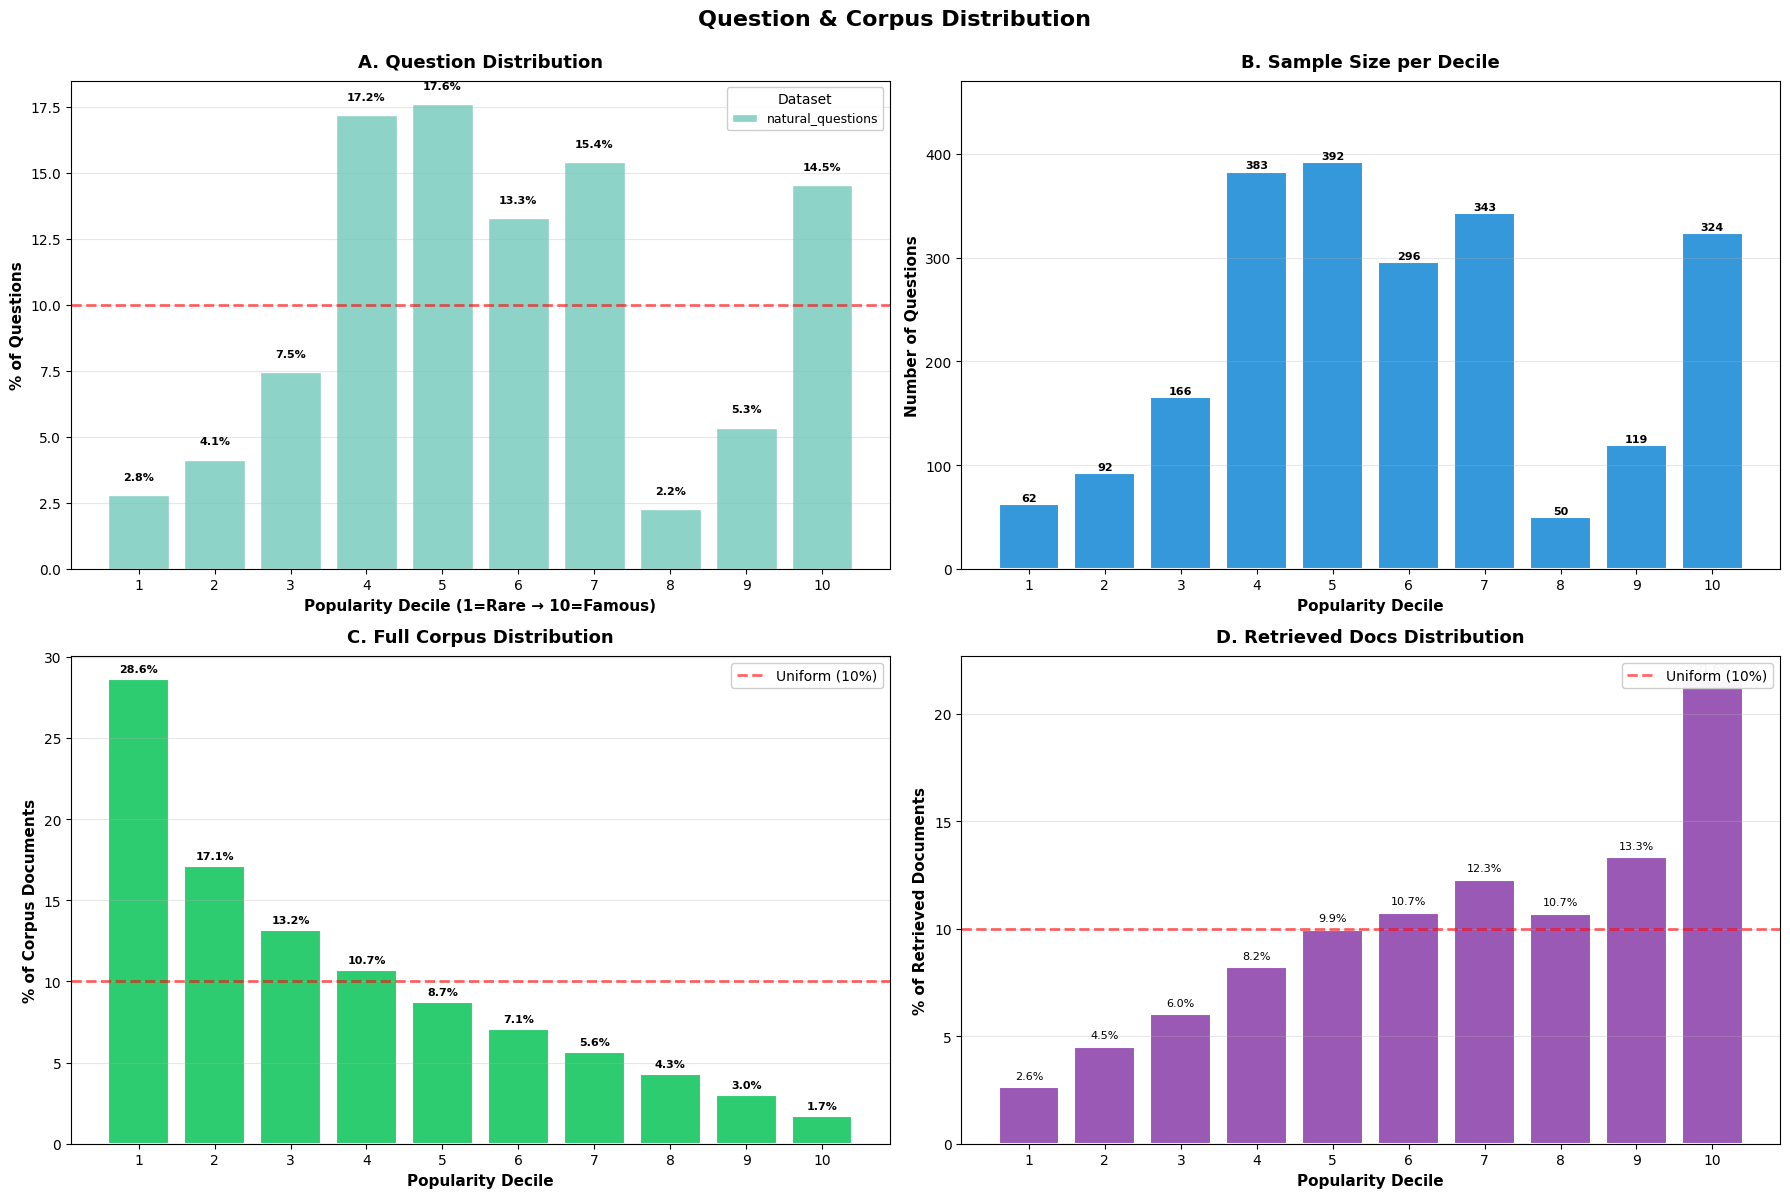

✓ Saved to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/nq_500/distribution_overview.png


In [4]:
# ============================================================================
# 4. Question & Corpus Distribution
# ============================================================================

results_df = results_by_strategy[ALL_STRATEGIES[0]]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# --- Panel A: Question Distribution by Popularity Decile ---
ax = axes[0]
if "dataset" in results_df.columns:
    datasets = sorted(results_df["dataset"].dropna().unique())
    bottoms = np.zeros(10)
    colors = plt.cm.Set3.colors
    for i, ds in enumerate(datasets):
        ds_counts = results_df[results_df["dataset"] == ds]["pop_decile"].value_counts().reindex(range(10), fill_value=0)
        ds_pcts = (ds_counts / len(results_df)) * 100
        ax.bar(np.arange(1, 11), ds_pcts.values, bottom=bottoms, color=colors[i % len(colors)],
               edgecolor='white', linewidth=1.0, label=ds)
        bottoms += ds_pcts.values
    for i, total in enumerate(bottoms):
        if total > 0.5:
            ax.text(i + 1, total + 0.5, f'{total:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95, title="Dataset")
else:
    q_counts = results_df['pop_decile'].value_counts().sort_index()
    q_pcts = (q_counts / len(results_df)) * 100
    ax.bar(np.arange(1, 11), q_pcts.values, color='#3498db', edgecolor='white', linewidth=1.5)
    for i, val in enumerate(q_pcts.values):
        if val > 0.5:
            ax.text(i + 1, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
ax.set_xlabel("Popularity Decile (1=Rare → 10=Famous)", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Questions", fontsize=11, fontweight='bold')
ax.set_title("A. Question Distribution", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel B: Sample Size per Decile ---
ax = axes[1]
sample_sizes = results_df.groupby("pop_decile").size().reindex(range(10), fill_value=0)
bars = ax.bar(np.arange(1, 11), sample_sizes.values, color='#3498db', edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sample_sizes.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{int(val)}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("Number of Questions", fontsize=11, fontweight='bold')
ax.set_title("B. Sample Size per Decile", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, sample_sizes.max() * 1.2 if sample_sizes.max() > 0 else 10)

# --- Panel C: Full Corpus Distribution ---
ax = axes[2]
print("Calculating corpus distribution...")

# Try to load from metadata first
corpus_distribution = None
if metadata_path.exists():
    with open(metadata_path) as f:
        meta = json.load(f)
    
    decile_key = "corpus_distribution_weighted" if USE_WEIGHTED_DECILES else "corpus_distribution_unweighted"
    if decile_key in meta:
        corpus_distribution = np.array(meta[decile_key])
        print(f"  ✓ Loaded {decile_key} from metadata")

# If not in metadata, calculate from corpus
if corpus_distribution is None:
    corpus_parquet = CORPUS_PATH
    if corpus_parquet.exists():
        import pyarrow.parquet as pq
        
        pf = pq.ParquetFile(corpus_parquet)
        decile_counts = np.zeros(10)
        
        for batch in tqdm(pf.iter_batches(batch_size=50_000, columns=["popularity_avg"]), 
                         desc="Scanning corpus", leave=False):
            batch_df = batch.to_pandas()
            valid = batch_df.dropna(subset=["popularity_avg"])
            valid = valid[valid["popularity_avg"] >= 0]
            
            if len(valid) > 0:
                batch_deciles = pd.cut(valid["popularity_avg"], bins=corpus_bin_edges, 
                                      labels=False, include_lowest=True)
                for d in range(10):
                    decile_counts[d] += (batch_deciles == d).sum()
        
        corpus_distribution = (decile_counts / decile_counts.sum()) * 100
        print(f"  ✓ Calculated from {corpus_parquet.name}")
    else:
        print(f"  ⚠ Corpus file not found: {corpus_parquet}")

if corpus_distribution is not None:
    bars = ax.bar(np.arange(1, 11), corpus_distribution, color='#2ecc71', edgecolor='white', linewidth=1.5)
    for i, val in enumerate(corpus_distribution):
        if val > 0.5:
            ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
else:
    ax.text(0.5, 0.5, 'Corpus distribution not available', ha='center', va='center', 
            transform=ax.transAxes, fontsize=12, style='italic')

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Corpus Documents", fontsize=11, fontweight='bold')
ax.set_title("C. Full Corpus Distribution", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

# --- Panel D: Retrieved Docs Distribution ---
ax = axes[3]
all_retrieved_pops = []
for pops_list in results_df["topk_popularities"]:
    if pops_list is not None and len(pops_list) > 0:
        all_retrieved_pops.extend([p for p in pops_list if p is not None and p >= 0])

if all_retrieved_pops:
    corpus_deciles = pd.cut(all_retrieved_pops, bins=corpus_bin_edges, labels=False, include_lowest=True)
    corpus_counts = pd.Series(corpus_deciles).value_counts().sort_index()
    corpus_pcts = (corpus_counts / len(corpus_deciles)) * 100
    bars = ax.bar(np.arange(1, 11), corpus_pcts.reindex(range(10), fill_value=0).values, 
                  color='#9b59b6', edgecolor='white', linewidth=1.5)
    for i, val in enumerate(corpus_pcts.reindex(range(10), fill_value=0).values):
        if val > 0.5:
            ax.text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.axhline(10, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Uniform (10%)')
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

ax.set_xlabel("Popularity Decile", fontsize=11, fontweight='bold')
ax.set_ylabel("% of Retrieved Documents", fontsize=11, fontweight='bold')
ax.set_title("D. Retrieved Docs Distribution", fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1, 11))

plt.suptitle("Question & Corpus Distribution", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "distribution_overview.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {RESULTS_DIR / 'distribution_overview.png'}")

---

# Part II: Retrieval Performance

Overall retrieval quality across strategies, then broken down by popularity decile.

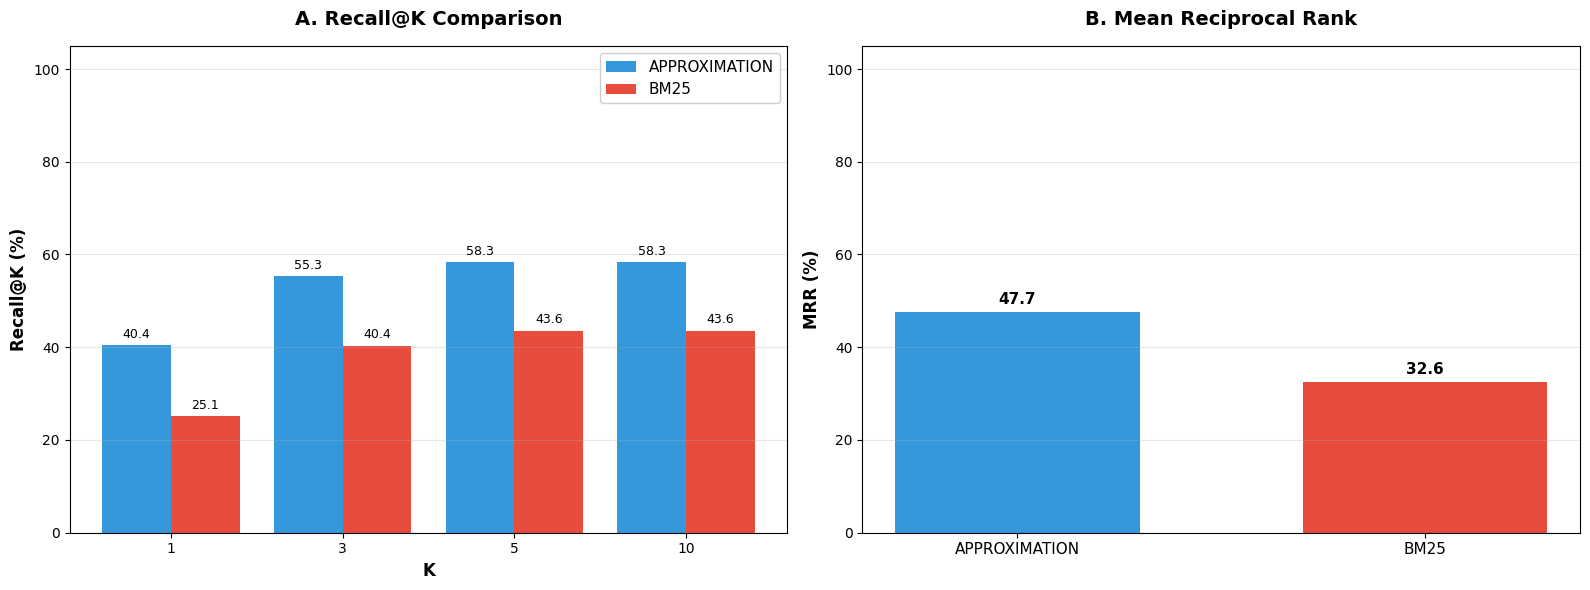

✓ Saved to /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/nq_500/performance_overview.png


In [5]:
# ============================================================================
# 5. Recall@K & MRR Overview
# ============================================================================

strategy_colors = {'approximation': '#3498db', 'vector': '#3498db', 'bm25': '#e74c3c', 'hybrid': '#27ae60'}
markers = {'approximation': 'o', 'vector': 'o', 'bm25': 's', 'hybrid': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: Recall@K Comparison ---
ax = axes[0]
x = np.arange(len(K_VALUES_DETAILED))
width = 0.8 / len(ALL_STRATEGIES)

for i, strategy in enumerate(ALL_STRATEGIES):
    recalls = [metrics_by_strategy[strategy][f"recall@{k}"] for k in K_VALUES_DETAILED]
    color = strategy_colors.get(strategy, plt.cm.tab10.colors[i])
    bars = ax.bar(x + i*width, np.array(recalls) * 100, width, label=strategy.upper(), color=color)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall@K (%)', fontsize=12, fontweight='bold')
ax.set_title('A. Recall@K Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * (len(ALL_STRATEGIES)-1) / 2)
ax.set_xticklabels(K_VALUES_DETAILED)
ax.legend(fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

# --- Panel B: MRR Comparison ---
ax = axes[1]
mrr_values = [metrics_by_strategy[s]["mrr"] * 100 for s in ALL_STRATEGIES]
colors = [strategy_colors.get(s, plt.cm.tab10.colors[i]) for i, s in enumerate(ALL_STRATEGIES)]
bars = ax.bar(range(len(ALL_STRATEGIES)), mrr_values, color=colors, width=0.6)
for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('MRR (%)', fontsize=12, fontweight='bold')
ax.set_title('B. Mean Reciprocal Rank', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(ALL_STRATEGIES)))
ax.set_xticklabels([s.upper() for s in ALL_STRATEGIES], fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "performance_overview.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {RESULTS_DIR / 'performance_overview.png'}")

### 6. Performance Across Popularity Deciles

The key question: **does retrieval quality depend on how popular the target entity is?**  
- Left: Recall@K at the primary threshold, split by decile — a flat line means no bias  
- Right: MRR by decile — same story from the ranking perspective

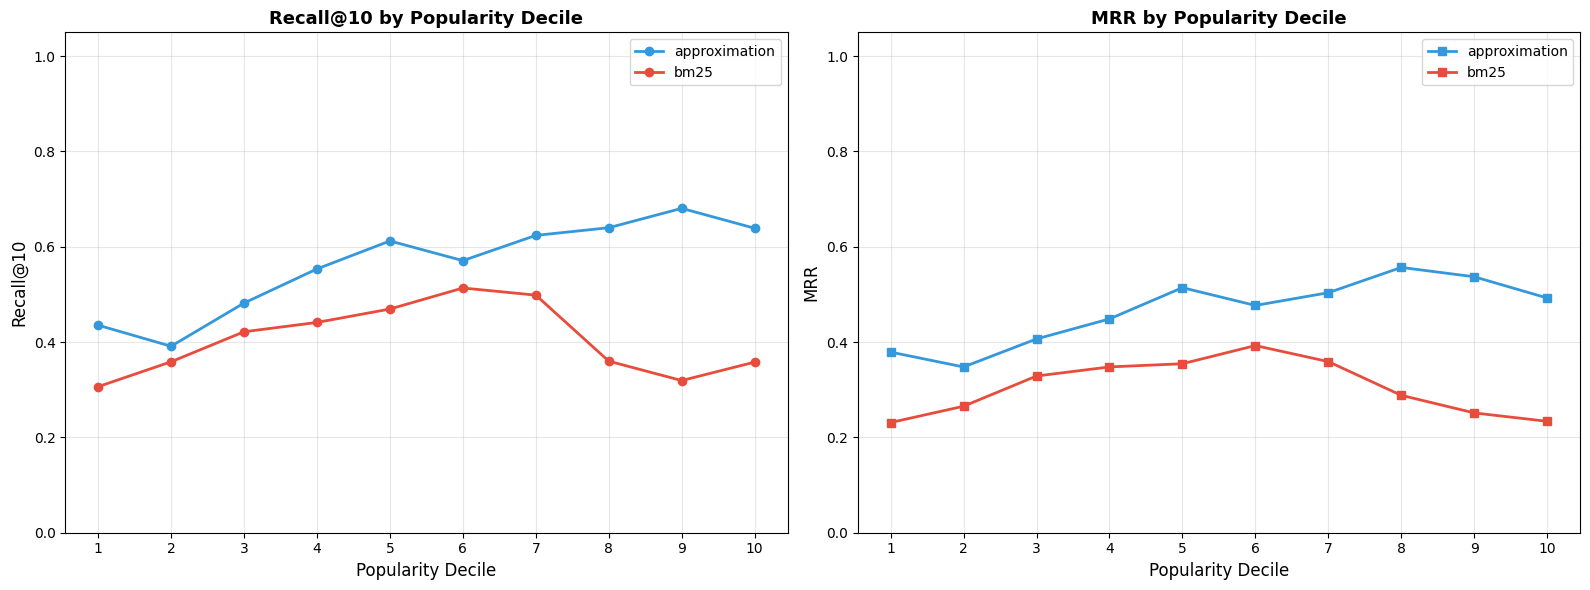

Saved  → per_decile_performance.png


In [6]:
# ============================================================================
# Per-Decile Recall@K  &  MRR
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

primary_k = K_VALUES_DETAILED[-1]          # e.g. 10

# ---- Panel A: Recall@K per decile (line plot) ----------------------------
ax = axes[0]
for strategy in STRATEGIES:
    dm = decile_metrics_by_strategy[strategy]
    col = f'recall@{primary_k}'
    if col in dm.columns:
        ax.plot(dm['decile'] + 1, dm[col],
                marker='o', linewidth=2, markersize=6,
                color=strategy_colors.get(strategy, '#333'),
                label=f'{strategy}')
ax.set_xlabel('Popularity Decile', fontsize=12)
ax.set_ylabel(f'Recall@{primary_k}', fontsize=12)
ax.set_title(f'Recall@{primary_k} by Popularity Decile', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# ---- Panel B: MRR per decile (line plot) ----------------------------------
ax = axes[1]
for strategy in STRATEGIES:
    dm = decile_metrics_by_strategy[strategy]
    if 'mrr' in dm.columns:
        ax.plot(dm['decile'] + 1, dm['mrr'],
                marker='s', linewidth=2, markersize=6,
                color=strategy_colors.get(strategy, '#333'),
                label=f'{strategy}')
ax.set_xlabel('Popularity Decile', fontsize=12)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('MRR by Popularity Decile', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(str(RESULTS_DIR), 'per_decile_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved  → per_decile_performance.png")

# Part III: Fairness & Popularity Bias Analysis

Now that we know *how well* each strategy retrieves, we investigate *how fairly* it retrieves.

- **Expected vs. Retrieved popularity**: do retrieved documents come from the same popularity tier as the question target?
- **Popularity preference**: when the system retrieves the wrong document, is that document *more popular* than the correct one?
- **Where do wrong documents come from?** — per-decile origin analysis

### 7. Expected vs. Retrieved Popularity Heatmap

Each cell $(i, j)$ shows the fraction of questions whose target is in popularity decile $i$ but whose **top-1 retrieved document** falls into corpus-popularity decile $j$.  
A perfectly unbiased system concentrates mass on the diagonal (green squares).

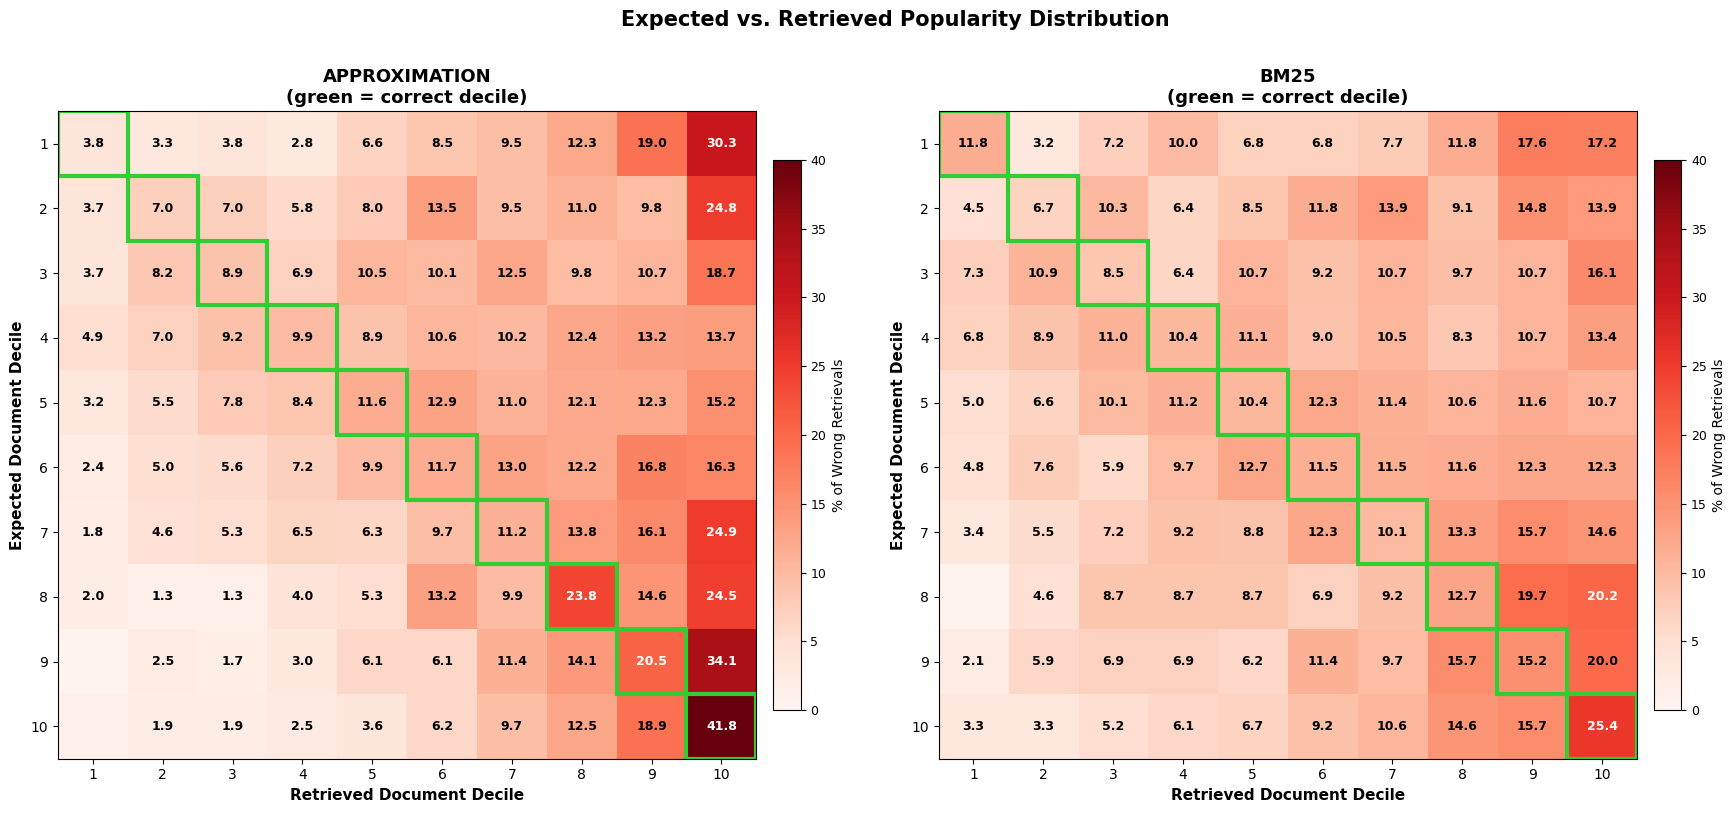

Saved  → expected_vs_retrieved_heatmap.png


In [7]:
# ============================================================================
# Expected vs Retrieved Popularity Heatmap  (one per strategy, side-by-side)
# ============================================================================

n_strats = len(STRATEGIES)
fig, axes = plt.subplots(1, n_strats, figsize=(9 * n_strats, 8))
if n_strats == 1:
    axes = [axes]

for ax, strategy in zip(axes, STRATEGIES):
    df = results_by_strategy[strategy]

    # Build heatmap: rows = expected decile, cols = retrieved decile
    hm = np.zeros((10, 10))
    for _, row in df.iterrows():
        expected_dec = int(row['pop_decile'])
        wrong_pops = row['wrong_docs_popularities']
        if wrong_pops is not None and len(wrong_pops) > 0:
            for wp in wrong_pops:
                wd = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
                if not pd.isna(wd):
                    hm[expected_dec, int(wd)] += 1

    row_sums = hm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    hm_pct = hm / row_sums * 100

    im = ax.imshow(hm_pct, aspect='auto', cmap='Reds', vmin=0, vmax=40)
    cbar = plt.colorbar(im, ax=ax, label='% of Wrong Retrievals', pad=0.02, shrink=0.85)
    cbar.ax.tick_params(labelsize=9)

    for i in range(10):
        for j in range(10):
            if hm_pct[i, j] > 1:
                colour = 'white' if hm_pct[i, j] > 20 else 'black'
                ax.text(j, i, f'{hm_pct[i, j]:.1f}', ha='center', va='center',
                        color=colour, fontsize=9, fontweight='bold')

    # Green diagonal highlights
    for i in range(10):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor='limegreen', linewidth=3))

    ax.set_xticks(range(10));  ax.set_xticklabels(range(1, 11))
    ax.set_yticks(range(10));  ax.set_yticklabels(range(1, 11))
    ax.set_xlabel('Retrieved Document Decile', fontsize=11, fontweight='bold')
    ax.set_ylabel('Expected Document Decile', fontsize=11, fontweight='bold')
    ax.set_title(f'{strategy.upper()}\n(green = correct decile)', fontsize=13, fontweight='bold')

plt.suptitle('Expected vs. Retrieved Popularity Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(str(RESULTS_DIR), 'expected_vs_retrieved_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved  → expected_vs_retrieved_heatmap.png")

### 8. Popularity Preference Curve

For each expected-popularity decile: when the system retrieves a **wrong** document, how often is that document **more popular** than the correct answer?

$$P(\text{wrong} > \text{expected}) = \frac{\#\{\text{wrong docs with pop} > \text{target pop}\}}{\#\{\text{all wrong docs}\}}$$

Values above 0.5 indicate a systematic preference for popular content.

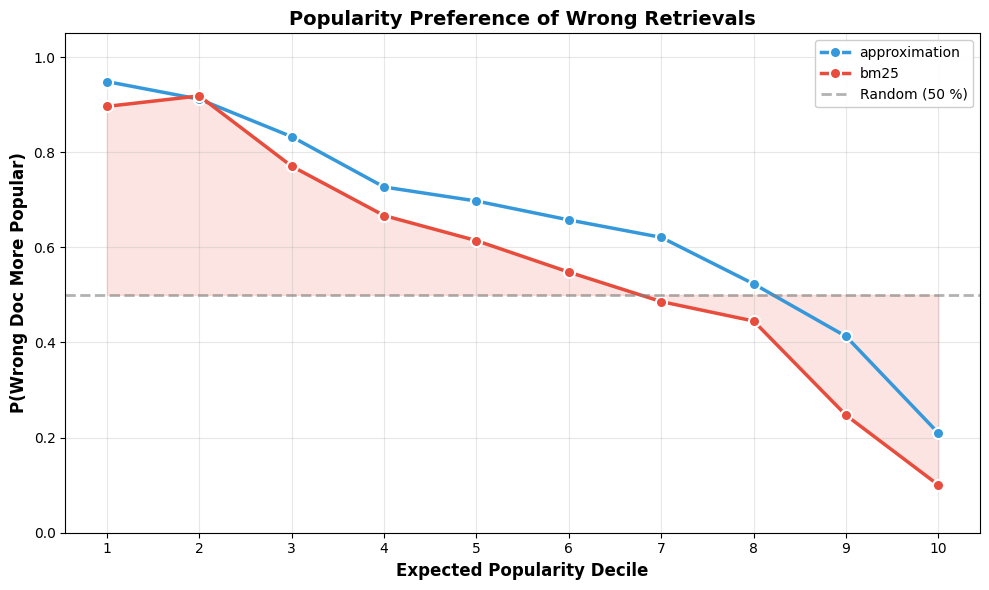

Saved  → popularity_preference.png


In [8]:
# ============================================================================
# Popularity Preference  (one line per strategy)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

for strategy in STRATEGIES:
    df = results_by_strategy[strategy]
    bias_per_decile = []

    for d in range(10):
        subset = df[df['pop_decile'] == d]
        n_higher, n_total = 0, 0

        for wp_list, pop in zip(subset['wrong_docs_popularities'], subset['popularity_avg']):
            if wp_list is None or len(wp_list) == 0 or pop is None:
                continue
            for wp in wp_list:
                n_total += 1
                if wp > pop:
                    n_higher += 1

        bias_per_decile.append(n_higher / n_total if n_total > 0 else 0.5)

    ax.plot(range(1, 11), bias_per_decile, marker='o', linewidth=2.5, markersize=8,
            color=strategy_colors.get(strategy, '#333'), label=strategy,
            markeredgewidth=1.5, markeredgecolor='white')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Random (50 %)')
ax.fill_between(range(1, 11), [0.5]*10, bias_per_decile, alpha=0.15,
                color=strategy_colors.get(STRATEGIES[-1], '#ccc'))

ax.set_xlabel('Expected Popularity Decile', fontsize=12, fontweight='bold')
ax.set_ylabel('P(Wrong Doc More Popular)', fontsize=12, fontweight='bold')
ax.set_title('Popularity Preference of Wrong Retrievals', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig(os.path.join(str(RESULTS_DIR), 'popularity_preference.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved  → popularity_preference.png")

### 9. Per-Decile Wrong Retrieval Origins

For each expected-popularity decile, where do the **wrongly retrieved** documents come from?  
Each subplot is one expected decile; bars show the popularity distribution of wrong retrievals.  
The green-bordered bar marks the "same decile" — ideally the tallest bar.

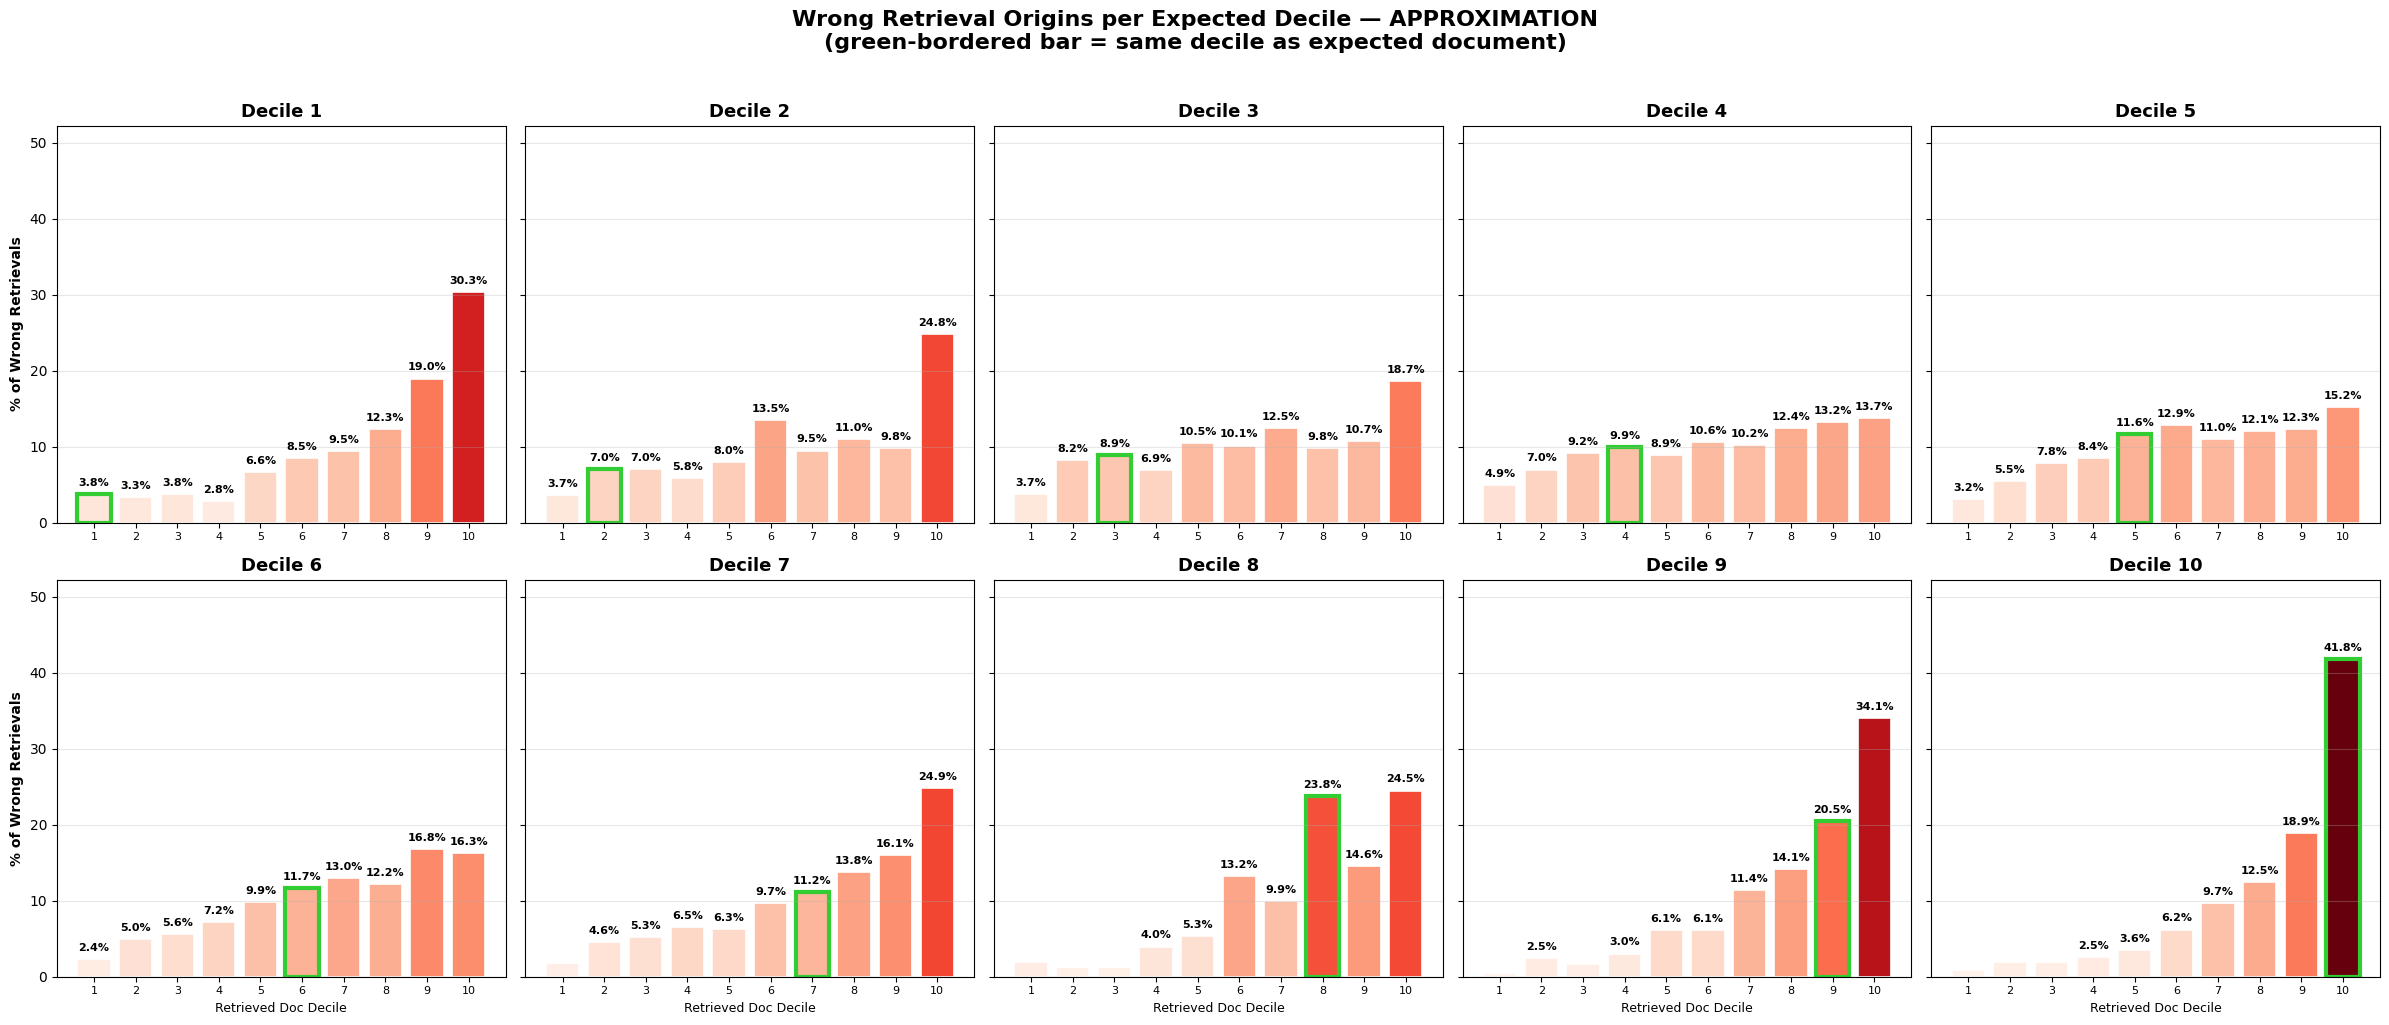

Saved  → wrong_retrieval_origins_approximation.png


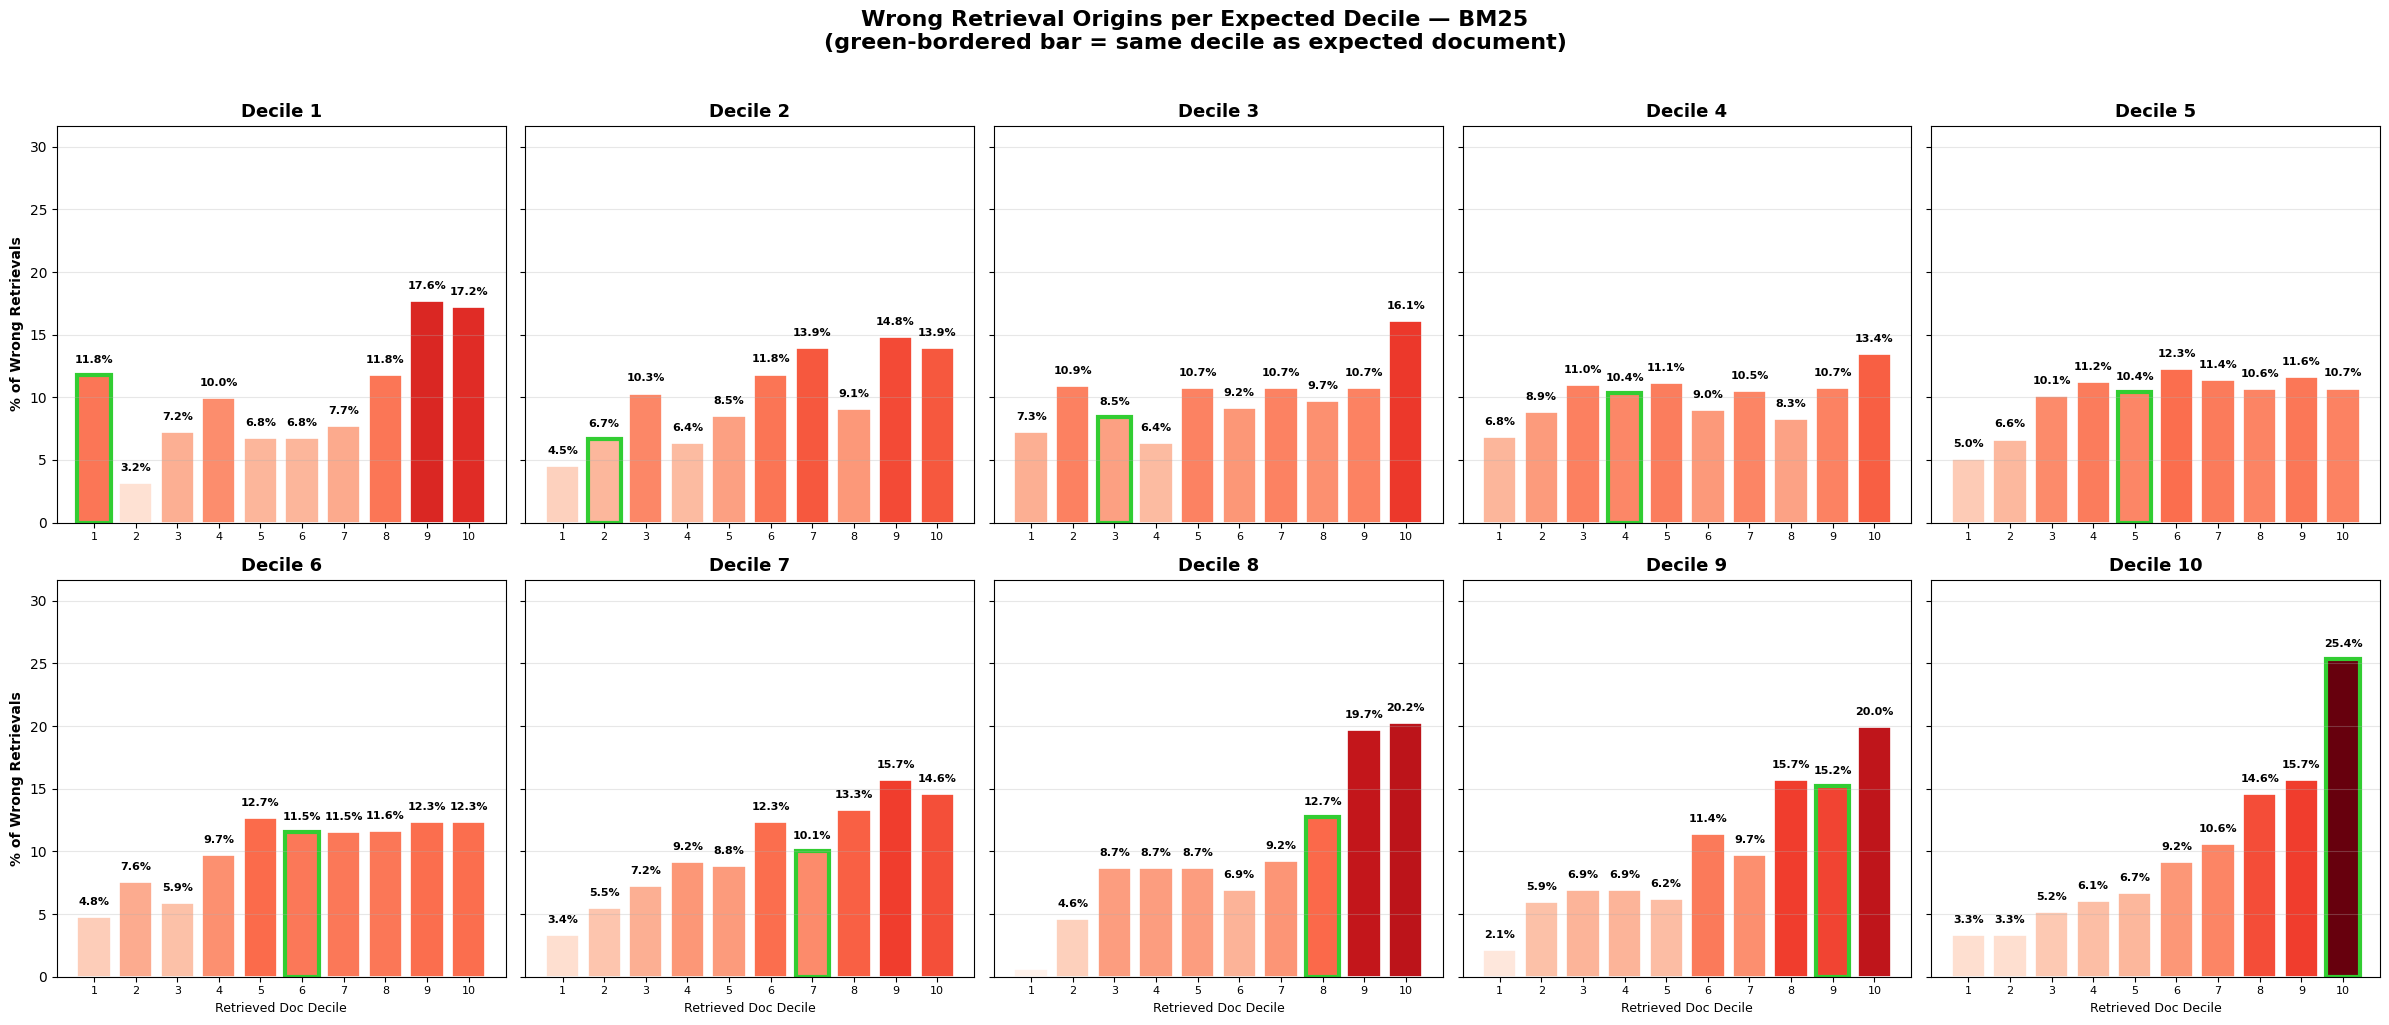

Saved  → wrong_retrieval_origins_bm25.png


In [9]:
# ============================================================================
# Per-Decile Wrong Retrieval Origins  (2×5 grid, one subplot per decile)
# ============================================================================

for strategy in STRATEGIES:
    df = results_by_strategy[strategy]

    # Build heatmap matrix
    hm = np.zeros((10, 10))
    for _, row in df.iterrows():
        expected_dec = int(row['pop_decile'])
        wrong_pops = row['wrong_docs_popularities']
        if wrong_pops is not None and len(wrong_pops) > 0:
            for wp in wrong_pops:
                wd = pd.cut([wp], bins=corpus_bin_edges, labels=False, include_lowest=True)[0]
                if not pd.isna(wd):
                    hm[expected_dec, int(wd)] += 1

    row_sums = hm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    hm_pct = hm / row_sums * 100

    fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharey=True)
    axes_flat = axes.flatten()
    cmap = plt.cm.Reds
    norm = plt.Normalize(vmin=0, vmax=hm_pct.max())

    for decile in range(10):
        ax = axes_flat[decile]
        values = hm_pct[decile]
        colors = [cmap(norm(v)) for v in values]

        bars = ax.bar(np.arange(1, 11), values, color=colors, edgecolor='white', linewidth=1.2)

        # Highlight "same decile" bar
        bars[decile].set_edgecolor('limegreen')
        bars[decile].set_linewidth(3)

        for i, val in enumerate(values):
            if val > 2:
                ax.text(i + 1, val + 0.8, f'{val:.1f}%', ha='center', va='bottom',
                        fontsize=8, fontweight='bold')

        ax.set_title(f'Decile {decile + 1}', fontsize=13, fontweight='bold')
        ax.set_xticks(range(1, 11))
        ax.set_xticklabels(range(1, 11), fontsize=8)
        ax.set_ylim(0, hm_pct.max() * 1.25)
        ax.grid(axis='y', alpha=0.3)

        if decile % 5 == 0:
            ax.set_ylabel('% of Wrong Retrievals', fontsize=10, fontweight='bold')
        if decile >= 5:
            ax.set_xlabel('Retrieved Doc Decile', fontsize=9)

    fig.suptitle(
        f'Wrong Retrieval Origins per Expected Decile — {strategy.upper()}\n'
        '(green-bordered bar = same decile as expected document)',
        fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(str(RESULTS_DIR), f'wrong_retrieval_origins_{strategy}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved  → wrong_retrieval_origins_{strategy}.png")

# Part IV: Export & Summary

Save per-decile metrics and key findings for downstream use.

In [10]:
# ============================================================================
# Save per-decile CSVs  &  print key findings
# ============================================================================

for strategy in STRATEGIES:
    dm = decile_metrics_by_strategy[strategy]
    path = os.path.join(str(RESULTS_DIR), f'per_decile_{strategy}.csv')
    dm.to_csv(path, index=False)
    print(f"Saved  → {path}")

# ---------- Aggregate metrics comparison table ----------
rows = []
for strategy in STRATEGIES:
    metrics = metrics_by_strategy[strategy]
    
    row = {'strategy': strategy}
    for k in K_VALUES_DETAILED:
        row[f'recall@{k}'] = (metrics[f'recall@{k}'] * 100).round(2)
    row['mrr'] = (metrics['mrr']).round(4)
    row['median_rank'] = metrics.get('median_rank')
    rows.append(row)

comparison = pd.DataFrame(rows)
comp_path = os.path.join(str(RESULTS_DIR), 'metrics_comparison.csv')
comparison.to_csv(comp_path, index=False)
print(f"Saved  → {comp_path}")
print()
display(comparison)

Saved  → /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/nq_500/per_decile_approximation.csv
Saved  → /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/nq_500/per_decile_bm25.csv
Saved  → /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full/nq_500/metrics_comparison.csv



,strategy,recall@1,recall@3,recall@5,recall@10,mrr,median_rank
0,approximation,40.41,55.32,58.28,58.28,0.4767,1.0
1,bm25,25.10,40.37,43.56,43.56,0.3256,1.0
